In [ ]:
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from datetime import datetime

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path

# Folder containing all CSV files:
# dataset_satellite_raw_2018-12-12.csv
# dataset_satellite_raw_2018-12-17.csv
# ...
RAW_FOLDER = Path('/content/drive/MyDrive/Archivos_Jammes/Proyecto/BiomasAndinos/RawData/')

# Folder where results will be saved
PROJECT_DIR = Path('/content/drive/MyDrive/Archivos_Jammes/Proyecto/BiomasAndinos/Results/')
PROJECT_DIR.mkdir(parents=True, exist_ok=True)

START_DATE = "2018-12-12"
END_DATE   = "2026-03-27"
FREQ = "5D"

print("Raw folder:", RAW_FOLDER)
print("Results folder:", PROJECT_DIR)

Raw folder: /content/drive/MyDrive/Archivos_Jammes/Proyecto/BiomasAndinos/RawData
Results folder: /content/drive/MyDrive/Archivos_Jammes/Proyecto/BiomasAndinos/Results


In [ ]:
def extract_date_from_filename(path):
    """
    Extracts YYYY-MM-DD from a filename.
    Example: dataset_satellite_raw_2018-12-12.csv
    """
    match = re.search(r"\d{4}-\d{2}-\d{2}", path.name)
    if match is None:
        raise ValueError(f"No date found in filename: {path.name}")
    return pd.to_datetime(match.group(0))


def load_one_csv(path):
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()

    date = extract_date_from_filename(path)
    df["date"] = date
    df["source_file"] = path.name

    # If no pixel id exists, use row index as pixel id
    possible_id_cols = ["pixel_id", "Pixel_ID", "id", "ID"]
    found_id = None

    for col in possible_id_cols:
        if col in df.columns:
            found_id = col
            break

    if found_id is None:
        df["pixel_id"] = np.arange(len(df))
    else:
        df = df.rename(columns={found_id: "pixel_id"})

    return df


csv_files = sorted(RAW_FOLDER.glob("*.csv"))

if len(csv_files) == 0:
    raise FileNotFoundError(f"No CSV files found in {RAW_FOLDER}")

print(f"Found {len(csv_files)} CSV files.")

df_all = pd.concat([load_one_csv(path) for path in csv_files], ignore_index=True)

df_all["date"] = pd.to_datetime(df_all["date"])
df_all = df_all.sort_values(["pixel_id", "date"]).reset_index(drop=True)

print(df_all.shape)
df_all.head()

Found 524 CSV files.
(523182, 19)


,B1,B11,B12,B2,B3,B4,B5,B6,B7,B8,B8A,B9,BSI,CLOUD_PERCENTAGE,NDMI,NDVI,date,source_file,pixel_id
0,3004.0,3107.0,2578.0,2834.0,2972.0,3010.0,3265.0,3725.0,3961.0,3764.0,4130.0,5147.0,-0.037829,0,0.095619,0.111308,2018-12-12,dataset_satellite_raw_2018-12-12.csv,0
1,198.0,2660.0,1608.0,339.0,581.0,731.0,979.0,1472.0,1713.0,1876.0,2035.0,1722.0,0.209775,0,-0.172840,0.439202,2018-12-17,dataset_satellite_raw_2018-12-17.csv,0
2,243.0,2208.0,1355.0,359.0,485.0,595.0,810.0,1191.0,1387.0,1504.0,1618.0,1643.0,0.201457,0,-0.189655,0.433063,2018-12-22,dataset_satellite_raw_2018-12-22.csv,0
3,452.0,2207.0,1329.0,467.0,590.0,681.0,895.0,1273.0,1438.0,1558.0,1702.0,1566.0,0.175656,0,-0.172377,0.391693,2018-12-27,dataset_satellite_raw_2018-12-27.csv,0
4,305.0,2263.0,1382.0,399.0,554.0,674.0,873.0,1244.0,1439.0,1612.0,1678.0,1642.0,0.187146,0,-0.168000,0.410324,2019-01-01,dataset_satellite_raw_2019-01-01.csv,0


In [ ]:
actual_dates = pd.Series(df_all["date"].unique()).sort_values().reset_index(drop=True)

expected_dates = pd.date_range(START_DATE, END_DATE, freq=FREQ)

# Include END_DATE even if it is not exactly aligned with 5-day frequency
end_date_ts = pd.to_datetime(END_DATE)
if end_date_ts not in expected_dates:
    expected_dates = expected_dates.union(pd.DatetimeIndex([end_date_ts]))

print("First actual date:", actual_dates.min())
print("Last actual date:", actual_dates.max())
print("Number of actual dates:", len(actual_dates))

print("First expected date:", expected_dates.min())
print("Last expected date:", expected_dates.max())
print("Number of expected dates:", len(expected_dates))

missing_dates = sorted(set(expected_dates) - set(actual_dates))
extra_dates = sorted(set(actual_dates) - set(expected_dates))

print("Missing expected dates:", len(missing_dates))
print("Extra actual dates:", len(extra_dates))

if len(missing_dates) > 0:
    print("Example missing dates:", missing_dates[:10])

if len(extra_dates) > 0:
    print("Example extra dates:", extra_dates[:10])

First actual date: 2018-12-12 00:00:00
Last actual date: 2026-03-27 00:00:00
Number of actual dates: 524
First expected date: 2018-12-12 00:00:00
Last expected date: 2026-03-27 00:00:00
Number of expected dates: 534
Missing expected dates: 386
Extra actual dates: 376
Example missing dates: [Timestamp('2020-11-01 00:00:00'), Timestamp('2020-11-21 00:00:00'), Timestamp('2020-12-16 00:00:00'), Timestamp('2020-12-31 00:00:00'), Timestamp('2021-01-05 00:00:00'), Timestamp('2021-01-10 00:00:00'), Timestamp('2021-01-15 00:00:00'), Timestamp('2021-01-20 00:00:00'), Timestamp('2021-01-25 00:00:00'), Timestamp('2021-01-30 00:00:00')]
Example extra dates: [Timestamp('2021-01-06 00:00:00'), Timestamp('2021-01-11 00:00:00'), Timestamp('2021-01-16 00:00:00'), Timestamp('2021-01-21 00:00:00'), Timestamp('2021-01-26 00:00:00'), Timestamp('2021-01-31 00:00:00'), Timestamp('2021-02-05 00:00:00'), Timestamp('2021-02-10 00:00:00'), Timestamp('2021-02-15 00:00:00'), Timestamp('2021-02-20 00:00:00')]


In [ ]:
BAND_COLS = [
    "B1", "B2", "B3", "B4", "B5", "B6", "B7",
    "B8", "B8A", "B9"]

INDEX_COLS = ["NDVI", "NDMI", "BSI"]

def safe_divide(numerator, denominator, small_value=1e-12):
    # Prevent division by zero or very small numbers
    return np.where(np.abs(denominator) < small_value, np.nan, numerator / denominator)

def prepare_features(df):
    df = df.copy()

    # Convert all relevant columns to numeric
    for col in BAND_COLS + INDEX_COLS + ["CLOUD_PERCENTAGE"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # Scale Sentinel bands if they are in 0-10000 scale
    for col in BAND_COLS:
        if col in df.columns:
            if df[col].quantile(0.95) > 2:
                df[col] = df[col] / 10000.0

    # Recompute NDVI if missing
    if "NDVI" not in df.columns and {"B8", "B4"}.issubset(df.columns):
        df["NDVI"] = safe_divide(df["B8"] - df["B4"], df["B8"] + df["B4"])

    # Recompute NDMI if missing
    if "NDMI" not in df.columns and {"B8", "B11"}.issubset(df.columns):
        df["NDMI"] = safe_divide(df["B8"] - df["B11"], df["B8"] + df["B11"])

    # Recompute BSI if missing
    if "BSI" not in df.columns and {"B11", "B4", "B8", "B2"}.issubset(df.columns):
        numerator = (df["B11"] + df["B4"]) - (df["B8"] + df["B2"])
        denominator = (df["B11"] + df["B4"]) + (df["B8"] + df["B2"])
        df["BSI"] = safe_divide(numerator, denominator)

    # Clip indices to reasonable physical ranges
    for col in ["NDVI", "NDMI", "BSI"]:
        if col in df.columns:
            df[col] = df[col].clip(-1, 1)

    if "CLOUD_PERCENTAGE" not in df.columns:
        df["CLOUD_PERCENTAGE"] = 0.0

    return df


df_all = prepare_features(df_all)

df_all.head()

,B1,B11,B12,B2,B3,B4,B5,B6,B7,B8,...,BSI,CLOUD_PERCENTAGE,NDMI,NDVI,date,source_file,pixel_id,NIRv,NIRv_z,biomass_proxy
0,0.3004,3107.0,2578.0,0.2834,0.2972,0.3010,0.3265,0.3725,0.3961,0.3764,...,-0.037829,0,0.095619,0.111308,2018-12-12,dataset_satellite_raw_2018-12-12.csv,0,0.041896,0.094792,0.601832
1,0.0198,2660.0,1608.0,0.0339,0.0581,0.0731,0.0979,0.1472,0.1713,0.1876,...,0.209775,0,-0.172840,0.439202,2018-12-17,dataset_satellite_raw_2018-12-17.csv,0,0.082394,0.575627,0.666294
2,0.0243,2208.0,1355.0,0.0359,0.0485,0.0595,0.0810,0.1191,0.1387,0.1504,...,0.201457,0,-0.189655,0.433063,2018-12-22,dataset_satellite_raw_2018-12-22.csv,0,0.065133,0.370680,0.642299
3,0.0452,2207.0,1329.0,0.0467,0.0590,0.0681,0.0895,0.1273,0.1438,0.1558,...,0.175656,0,-0.172377,0.391693,2018-12-27,dataset_satellite_raw_2018-12-27.csv,0,0.061026,0.321917,0.629400
4,0.0305,2263.0,1382.0,0.0399,0.0554,0.0674,0.0873,0.1244,0.1439,0.1612,...,0.187146,0,-0.168000,0.410324,2019-01-01,dataset_satellite_raw_2019-01-01.csv,0,0.066144,0.382689,0.642212


In [ ]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


def add_biomass_proxy(df):
    if {"NDVI", "B8"}.issubset(df.columns):
        df["NIRv"] = df["NDVI"] * df["B8"]
    else:
        df["NIRv"] = np.nan

    # Standardize NIRv robustly
    nirv_median = df["NIRv"].median()
    nirv_std = df["NIRv"].std()

    if pd.isna(nirv_std) or nirv_std == 0:
        df["NIRv_z"] = 0.0
    else:
        df["NIRv_z"] = (df["NIRv"] - nirv_median) / nirv_std

    # Biomass proxy in [0, 1]
    # Higher NDVI, NDMI, NIRv -> more biomass
    # Higher BSI -> more bare soil/degradation
    linear_score = (
        2.0 * df["NDVI"].fillna(0)
        + 1.2 * df["NDMI"].fillna(0)
        - 1.0 * df["BSI"].fillna(0)
        + 0.4 * df["NIRv_z"].fillna(0)
    )

    df["biomass_proxy"] = sigmoid(linear_score)

    return df


df_all = add_biomass_proxy(df_all)

df_all[["date", "pixel_id", "NDVI", "NDMI", "BSI", "NIRv", "biomass_proxy"]].head()

,date,pixel_id,NDVI,NDMI,BSI,NIRv,biomass_proxy
0,2018-12-12,0,0.111308,0.095619,-0.037829,0.041896,0.601832
1,2018-12-17,0,0.439202,-0.172840,0.209775,0.082394,0.666294
2,2018-12-22,0,0.433063,-0.189655,0.201457,0.065133,0.642299
3,2018-12-27,0,0.391693,-0.172377,0.175656,0.061026,0.629400
4,2019-01-01,0,0.410324,-0.168000,0.187146,0.066144,0.642212


In [ ]:
consolidated_path = PROJECT_DIR / "consolidated_satellite_timeseries_long.csv"
df_all.to_csv(consolidated_path, index=False)

print("Saved:", consolidated_path)

Saved: /content/drive/MyDrive/Archivos_Jammes/Proyecto/BiomasAndinos/Results/consolidated_satellite_timeseries_long.csv


In [ ]:
latex_table = df_all.head().to_latex(index=False)
print(latex_table)

\begin{tabular}{rrrrrrrrrrrrrrrrllrrrr}
\toprule
B1 & B11 & B12 & B2 & B3 & B4 & B5 & B6 & B7 & B8 & B8A & B9 & BSI & CLOUD_PERCENTAGE & NDMI & NDVI & date & source_file & pixel_id & NIRv & NIRv_z & biomass_proxy \\
\midrule
0.300400 & 3107.000000 & 2578.000000 & 0.283400 & 0.297200 & 0.301000 & 0.326500 & 0.372500 & 0.396100 & 0.376400 & 0.413000 & 0.514700 & -0.037829 & 0 & 0.095619 & 0.111308 & 2018-12-12 00:00:00 & dataset_satellite_raw_2018-12-12.csv & 0 & 0.041896 & 0.094792 & 0.601832 \\
0.019800 & 2660.000000 & 1608.000000 & 0.033900 & 0.058100 & 0.073100 & 0.097900 & 0.147200 & 0.171300 & 0.187600 & 0.203500 & 0.172200 & 0.209775 & 0 & -0.172840 & 0.439202 & 2018-12-17 00:00:00 & dataset_satellite_raw_2018-12-17.csv & 0 & 0.082394 & 0.575627 & 0.666294 \\
0.024300 & 2208.000000 & 1355.000000 & 0.035900 & 0.048500 & 0.059500 & 0.081000 & 0.119100 & 0.138700 & 0.150400 & 0.161800 & 0.164300 & 0.201457 & 0 & -0.189655 & 0.433063 & 2018-12-22 00:00:00 & dataset_satellite_raw_2018-

In [ ]:
display(df_all.head())

,B1,B11,B12,B2,B3,B4,B5,B6,B7,B8,...,BSI,CLOUD_PERCENTAGE,NDMI,NDVI,date,source_file,pixel_id,NIRv,NIRv_z,biomass_proxy
0,0.3004,3107.0,2578.0,0.2834,0.2972,0.3010,0.3265,0.3725,0.3961,0.3764,...,-0.037829,0,0.095619,0.111308,2018-12-12,dataset_satellite_raw_2018-12-12.csv,0,0.041896,0.094792,0.601832
1,0.0198,2660.0,1608.0,0.0339,0.0581,0.0731,0.0979,0.1472,0.1713,0.1876,...,0.209775,0,-0.172840,0.439202,2018-12-17,dataset_satellite_raw_2018-12-17.csv,0,0.082394,0.575627,0.666294
2,0.0243,2208.0,1355.0,0.0359,0.0485,0.0595,0.0810,0.1191,0.1387,0.1504,...,0.201457,0,-0.189655,0.433063,2018-12-22,dataset_satellite_raw_2018-12-22.csv,0,0.065133,0.370680,0.642299
3,0.0452,2207.0,1329.0,0.0467,0.0590,0.0681,0.0895,0.1273,0.1438,0.1558,...,0.175656,0,-0.172377,0.391693,2018-12-27,dataset_satellite_raw_2018-12-27.csv,0,0.061026,0.321917,0.629400
4,0.0305,2263.0,1382.0,0.0399,0.0554,0.0674,0.0873,0.1244,0.1439,0.1612,...,0.187146,0,-0.168000,0.410324,2019-01-01,dataset_satellite_raw_2019-01-01.csv,0,0.066144,0.382689,0.642212


In [ ]:
OBS_COLS = ["bits_mean = (
    df_all
    .groupby("date")[available_cols]
    .mean()
    .reindex(expected_dates)
)
omass_proxy", "NDVI", "NDMI", "BSI"]
AUX_COLS = ["CLOUD_PERCENTAGE"]

available_cols = [c for c in OBS_COLS + AUX_COLS if c in df_all.columns]


ts_mean.index.name = "date"
ts_mean = ts_mean.reset_index()

ts_mean.head()

,date,biomass_proxy,NDVI,NDMI,BSI,CLOUD_PERCENTAGE
0,2018-12-12,0.698378,0.274964,0.126197,-0.040577,0.0
1,2018-12-17,0.682757,0.269522,0.087274,-0.025533,0.0
2,2018-12-22,0.753033,0.441324,0.072608,-0.025746,0.0
3,2018-12-27,0.721285,0.366286,0.057137,-0.020042,0.0
4,2019-01-01,0.766957,0.468921,0.046942,-0.005485,0.0


In [ ]:
mean_path = PROJECT_DIR / "mean_5day_timeseries_for_ekf.csv"
ts_mean.to_csv(mean_path, index=False)

print("Saved:", mean_path)

Saved: /content/drive/MyDrive/Archivos_Jammes/Proyecto/BiomasAndinos/Results/mean_5day_timeseries_for_ekf.csv


In [ ]:
def f_state(x, dt=5/365):
    """
    Nonlinear process model.

    x[0] = true normalized biomass proxy
    x[1] = true NDVI
    x[2] = true NDMI
    x[3] = true BSI
    """
    agb, ndvi, ndmi, bsi = x

    r = 0.55          # growth persistence
    moisture_eff = 0.18
    degradation_eff = 0.12

    agb_next = agb + dt * (
        r * agb * (1 - agb)
        + moisture_eff * ndmi
        - degradation_eff * max(bsi, 0)
    )

    ndvi_next = 0.96 * ndvi + 0.03 * agb + 0.02 * ndmi - 0.01 * bsi
    ndmi_next = 0.94 * ndmi + 0.04 * agb
    bsi_next  = 0.95 * bsi - 0.02 * agb

    return np.array([
        agb_next,
        ndvi_next,
        ndmi_next,
        bsi_next
    ], dtype=float)


def jacobian_f(x, dt=5/365):
    """
    Jacobian of f_state.
    """
    agb, ndvi, ndmi, bsi = x

    r = 0.55
    moisture_eff = 0.18
    degradation_eff = 0.12

    F = np.eye(4)

    # d agb_next / d agb
    F[0, 0] = 1 + dt * r * (1 - 2 * agb)

    # d agb_next / d ndmi
    F[0, 2] = dt * moisture_eff

    # d agb_next / d bsi
    F[0, 3] = -dt * degradation_eff if bsi > 0 else 0.0

    # NDVI equation
    F[1, 0] = 0.03
    F[1, 1] = 0.96
    F[1, 2] = 0.02
    F[1, 3] = -0.01

    # NDMI equation
    F[2, 0] = 0.04
    F[2, 2] = 0.94

    # BSI equation
    F[3, 0] = -0.02
    F[3, 3] = 0.95

    return F


def h_obs(x):
    """
    Observation model.
    Here observations directly measure the noisy version of the state.
    """
    return x.copy()


def jacobian_h(x):
    """
    Jacobian of h_obs.
    """
    return np.eye(4)

In [ ]:
def run_ekf(ts):
    """
    Runs EKF over a time series with columns:
    date, biomass_proxy, NDVI, NDMI, BSI, CLOUD_PERCENTAGE
    """
    ts = ts.copy().sort_values("date").reset_index(drop=True)

    z_cols = ["biomass_proxy", "NDVI", "NDMI", "BSI"]

    Z = ts[z_cols].to_numpy(dtype=float)

    if "CLOUD_PERCENTAGE" in ts.columns:
        cloud = ts["CLOUD_PERCENTAGE"].fillna(0).to_numpy(dtype=float)
    else:
        cloud = np.zeros(len(ts))

    # Initial state from first valid observation
    valid_rows = np.where(np.isfinite(Z).all(axis=1))[0]

    if len(valid_rows) == 0:
        x = np.array([0.5, 0.3, 0.1, 0.0], dtype=float)
    else:
        x = Z[valid_rows[0]].copy()

    # Initial covariance
    P = np.diag([0.08, 0.06, 0.06, 0.06])

    # Process noise
    Q = np.diag([0.002, 0.001, 0.001, 0.001])

    # Base observation noise
    R_base = np.diag([0.015, 0.010, 0.010, 0.010])

    results = []

    for t in range(len(ts)):
        date_t = ts.loc[t, "date"]

        # Prediction
        F = jacobian_f(x)
        x_pred = f_state(x)
        P_pred = F @ P @ F.T + Q

        z_t = Z[t]
        valid = np.isfinite(z_t)

        # Cloud-aware observation uncertainty
        cloud_factor = 1.0 + cloud[t] / 20.0
        R_t = R_base * cloud_factor

        if valid.any():
            H_full = jacobian_h(x_pred)
            H = H_full[valid, :]
            z_valid = z_t[valid]
            h_valid = h_obs(x_pred)[valid]
            R_valid = R_t[np.ix_(valid, valid)]

            innovation = z_valid - h_valid
            S = H @ P_pred @ H.T + R_valid
            K = P_pred @ H.T @ np.linalg.inv(S)

            x = x_pred + K @ innovation

            I = np.eye(len(x))
            P = (I - K @ H) @ P_pred @ (I - K @ H).T + K @ R_valid @ K.T
        else:
            x = x_pred
            P = P_pred

        # Keep states in realistic ranges
        x[0] = np.clip(x[0], 0, 1)
        x[1] = np.clip(x[1], -1, 1)
        x[2] = np.clip(x[2], -1, 1)
        x[3] = np.clip(x[3], -1, 1)

        results.append({
            "date": date_t,
            "AGB_proxy_filtered": x[0],
            "NDVI_filtered": x[1],
            "NDMI_filtered": x[2],
            "BSI_filtered": x[3],
            "var_AGB_proxy": P[0, 0],
            "var_NDVI": P[1, 1],
            "var_NDMI": P[2, 2],
            "var_BSI": P[3, 3],
            "CLOUD_PERCENTAGE": cloud[t],
            "AGB_proxy_observed": z_t[0],
            "NDVI_observed": z_t[1],
            "NDMI_observed": z_t[2],
            "BSI_observed": z_t[3],
        })

    return pd.DataFrame(results)

In [ ]:
ekf_mean = run_ekf(ts_mean)

ekf_mean_path = PROJECT_DIR / "ekf_filtered_mean_timeseries.csv"
ekf_mean.to_csv(ekf_mean_path, index=False)

print("Saved:", ekf_mean_path)
ekf_mean.head()

Saved: /content/drive/MyDrive/Archivos_Jammes/Proyecto/BiomasAndinos/Results/ekf_filtered_mean_timeseries.csv


,date,AGB_proxy_filtered,NDVI_filtered,NDMI_filtered,BSI_filtered,var_AGB_proxy,var_NDVI,var_NDMI,var_BSI,CLOUD_PERCENTAGE,AGB_proxy_observed,NDVI_observed,NDMI_observed,BSI_observed
0,2018-12-12,0.698396,0.276829,0.129334,-0.042387,0.012662,0.008492,0.008438,0.008465,0.0,0.698378,0.274964,0.126197,-0.040577
1,2018-12-17,0.690192,0.279683,0.120665,-0.040771,0.007387,0.004691,0.004585,0.004636,0.0,0.682757,0.269522,0.087274,-0.025533
2,2018-12-22,0.715917,0.343980,0.119729,-0.044204,0.005749,0.003479,0.003362,0.003416,0.0,0.753033,0.441324,0.072608,-0.025746
3,2018-12-27,0.717152,0.357370,0.117336,-0.045807,0.005084,0.002967,0.002850,0.002901,0.0,0.721285,0.366286,0.057137,-0.020042
4,2019-01-01,0.733439,0.394714,0.116231,-0.044522,0.004788,0.002725,0.002610,0.002659,0.0,0.766957,0.468921,0.046942,-0.005485


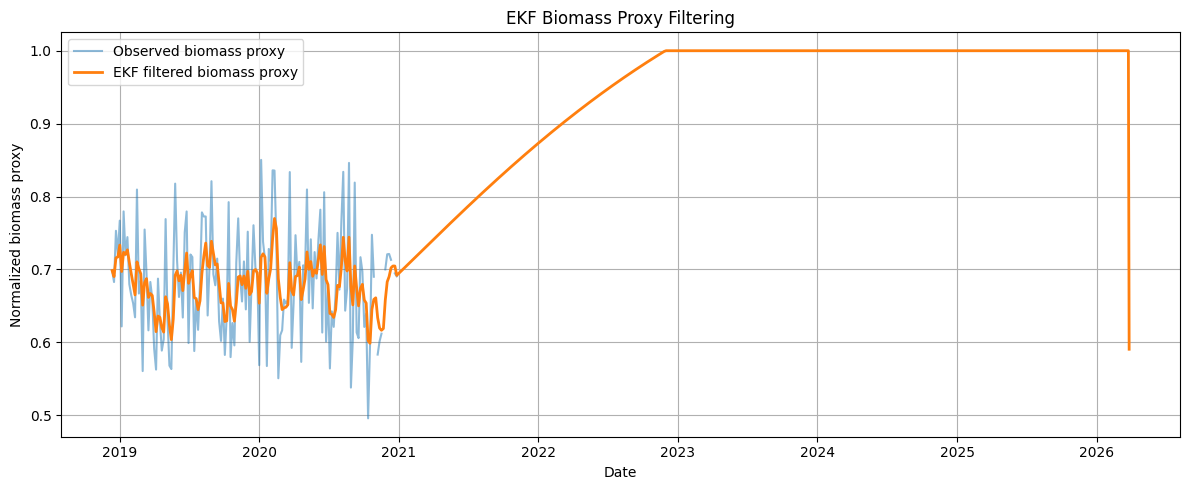

Saved: /content/drive/MyDrive/Archivos_Jammes/Proyecto/BiomasAndinos/Results/ekf_biomass_proxy_filtered.png


In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(ekf_mean["date"], ekf_mean["AGB_proxy_observed"], label="Observed biomass proxy", alpha=0.5)
plt.plot(ekf_mean["date"], ekf_mean["AGB_proxy_filtered"], label="EKF filtered biomass proxy", linewidth=2)
plt.xlabel("Date")
plt.ylabel("Normalized biomass proxy")
plt.title("EKF Biomass Proxy Filtering")
plt.legend()
plt.grid(True)
plt.tight_layout()

fig_path = PROJECT_DIR / "ekf_biomass_proxy_filtered.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)

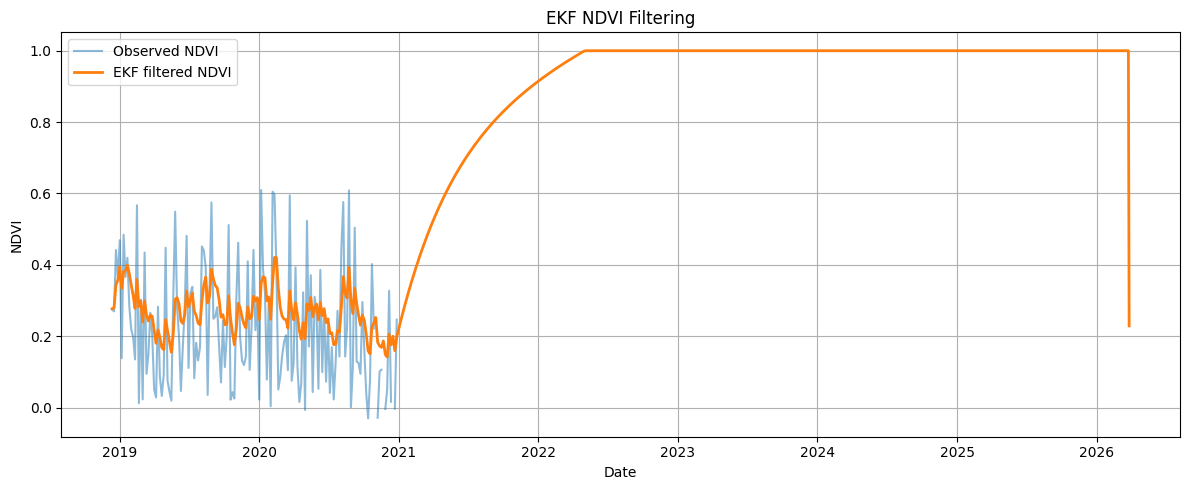

Saved: /content/drive/MyDrive/Archivos_Jammes/Proyecto/BiomasAndinos/Results/ekf_ndvi_filtered.png


In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(ekf_mean["date"], ekf_mean["NDVI_observed"], label="Observed NDVI", alpha=0.5)
plt.plot(ekf_mean["date"], ekf_mean["NDVI_filtered"], label="EKF filtered NDVI", linewidth=2)
plt.xlabel("Date")
plt.ylabel("NDVI")
plt.title("EKF NDVI Filtering")
plt.legend()
plt.grid(True)
plt.tight_layout()

fig_path = PROJECT_DIR / "ekf_ndvi_filtered.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)

In [ ]:
if "Class" in df_all.columns:
    class_results = []

    for class_value, df_class in df_all.groupby("Class"):
        ts_class = (
            df_class
            .groupby("date")[available_cols]
            .mean()
            .reindex(expected_dates)
        )

        ts_class.index.name = "date"
        ts_class = ts_class.reset_index()

        ekf_class = run_ekf(ts_class)
        ekf_class["Class"] = class_value

        class_results.append(ekf_class)

    ekf_by_class = pd.concat(class_results, ignore_index=True)

    class_path = PROJECT_DIR / "ekf_filtered_by_class.csv"
    ekf_by_class.to_csv(class_path, index=False)

    print("Saved:", class_path)

else:
    print("No Class column found. Skipping class-specific EKF.")

No Class column found. Skipping class-specific EKF.


In [ ]:
RUN_PIXEL_EKF = True

if RUN_PIXEL_EKF:
    pixel_results = []

    for pixel_id, df_pixel in df_all.groupby("pixel_id"):
        ts_pixel = (
            df_pixel
            .set_index("date")[available_cols]
            .reindex(expected_dates)
        )

        ts_pixel.index.name = "date"
        ts_pixel = ts_pixel.reset_index()

        ekf_pixel = run_ekf(ts_pixel)
        ekf_pixel["pixel_id"] = pixel_id

        pixel_results.append(ekf_pixel)

    ekf_by_pixel = pd.concat(pixel_results, ignore_index=True)

    pixel_path = PROJECT_DIR / "ekf_filtered_by_pixel.csv"
    ekf_by_pixel.to_csv(pixel_path, index=False)

    print("Saved:", pixel_path)

Saved: /content/drive/MyDrive/Archivos_Jammes/Proyecto/BiomasAndinos/Results/ekf_filtered_by_pixel.csv


Dividing the set

In [ ]:
# ==========================================
# A. TRAIN / VALIDATION SPLIT
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Make sure PROJECT_DIR already exists from previous workflow
PROJECT_DIR.mkdir(parents=True, exist_ok=True)

# Unique dates available in the consolidated dataset
all_dates = pd.Series(df_all["date"].unique()).sort_values().reset_index(drop=True)

# 80% training, 20% validation
split_index = int(len(all_dates) * 0.80)

TRAIN_END_DATE = all_dates.iloc[split_index - 1]
VAL_START_DATE = all_dates.iloc[split_index]

print("Number of dates:", len(all_dates))
print("Training ends:", TRAIN_END_DATE)
print("Validation starts:", VAL_START_DATE)

df_all["set"] = np.where(df_all["date"] <= TRAIN_END_DATE, "train", "validation")

df_all[["date", "set"]].drop_duplicates().head(), df_all[["date", "set"]].drop_duplicates().tail()

Number of dates: 524
Training ends: 2024-10-17 00:00:00
Validation starts: 2024-10-22 00:00:00


(        date    set
 0 2018-12-12  train
 1 2018-12-17  train
 2 2018-12-22  train
 3 2018-12-27  train
 4 2019-01-01  train,
           date         set
 519 2026-03-07  validation
 520 2026-03-12  validation
 521 2026-03-17  validation
 522 2026-03-22  validation
 523 2026-03-27  validation)

In [ ]:
split_path = PROJECT_DIR / "consolidated_dataset_with_train_validation_split.csv"
df_all.to_csv(split_path, index=False)

print("Saved:", split_path)

Saved: /content/drive/MyDrive/Archivos_Jammes/Proyecto/BiomasAndinos/Results/consolidated_dataset_with_train_validation_split.csv


In [ ]:
# ==========================================
# B. EKF WITH TRAIN / VALIDATION ERROR
# ==========================================

def run_ekf_train_validation(ts, train_end_date, update_during_validation=True):
    """
    EKF for one time series.

    Parameters
    ----------
    ts : DataFrame
        Must contain:
        date, biomass_proxy, NDVI, NDMI, BSI, CLOUD_PERCENTAGE

    train_end_date : Timestamp
        Last date used as training.

    update_during_validation : bool
        True  -> one-step-ahead validation.
                 The prediction error is computed before update,
                 then the filter updates using the validation observation.
        False -> pure forecast validation.
                 After validation starts, the model does not update anymore.

    Returns
    -------
    DataFrame with filtered states and prediction errors.
    """

    ts = ts.copy().sort_values("date").reset_index(drop=True)

    z_cols = ["biomass_proxy", "NDVI", "NDMI", "BSI"]
    Z = ts[z_cols].to_numpy(dtype=float)

    if "CLOUD_PERCENTAGE" in ts.columns:
        cloud = ts["CLOUD_PERCENTAGE"].fillna(0).to_numpy(dtype=float)
    else:
        cloud = np.zeros(len(ts))

    # Initial state from first valid observation
    valid_rows = np.where(np.isfinite(Z).all(axis=1))[0]

    if len(valid_rows) == 0:
        x = np.array([0.5, 0.3, 0.1, 0.0], dtype=float)
    else:
        x = Z[valid_rows[0]].copy()

    # Initial uncertainty
    P = np.diag([0.08, 0.06, 0.06, 0.06])

    # Process noise
    Q = np.diag([0.002, 0.001, 0.001, 0.001])

    # Observation noise
    R_base = np.diag([0.015, 0.010, 0.010, 0.010])

    results = []

    for t in range(len(ts)):
        date_t = pd.to_datetime(ts.loc[t, "date"])
        z_t = Z[t]

        current_set = "train" if date_t <= train_end_date else "validation"

        # --------------------------
        # Prediction step
        # --------------------------
        F = jacobian_f(x)
        x_pred = f_state(x)
        P_pred = F @ P @ F.T + Q

        z_pred = h_obs(x_pred)

        # Prediction error BEFORE correction
        prediction_error = z_t - z_pred

        # --------------------------
        # Correction/update step
        # --------------------------
        valid = np.isfinite(z_t)

        cloud_factor = 1.0 + cloud[t] / 20.0
        R_t = R_base * cloud_factor

        should_update = (
            valid.any()
            and (
                current_set == "train"
                or update_during_validation
            )
        )

        if should_update:
            H_full = jacobian_h(x_pred)
            H = H_full[valid, :]
            z_valid = z_t[valid]
            h_valid = h_obs(x_pred)[valid]
            R_valid = R_t[np.ix_(valid, valid)]

            innovation = z_valid - h_valid
            S = H @ P_pred @ H.T + R_valid
            K = P_pred @ H.T @ np.linalg.inv(S)

            x = x_pred + K @ innovation

            I = np.eye(len(x))
            P = (I - K @ H) @ P_pred @ (I - K @ H).T + K @ R_valid @ K.T

        else:
            x = x_pred
            P = P_pred

        # Keep states in realistic ranges
        x[0] = np.clip(x[0], 0, 1)
        x[1] = np.clip(x[1], -1, 1)
        x[2] = np.clip(x[2], -1, 1)
        x[3] = np.clip(x[3], -1, 1)

        filtered_error = z_t - x

        results.append({
            "date": date_t,
            "set": current_set,

            "AGB_proxy_observed": z_t[0],
            "NDVI_observed": z_t[1],
            "NDMI_observed": z_t[2],
            "BSI_observed": z_t[3],

            "AGB_proxy_predicted": z_pred[0],
            "NDVI_predicted": z_pred[1],
            "NDMI_predicted": z_pred[2],
            "BSI_predicted": z_pred[3],

            "AGB_proxy_filtered": x[0],
            "NDVI_filtered": x[1],
            "NDMI_filtered": x[2],
            "BSI_filtered": x[3],

            "error_pred_AGB_proxy": prediction_error[0],
            "error_pred_NDVI": prediction_error[1],
            "error_pred_NDMI": prediction_error[2],
            "error_pred_BSI": prediction_error[3],

            "error_filt_AGB_proxy": filtered_error[0],
            "error_filt_NDVI": filtered_error[1],
            "error_filt_NDMI": filtered_error[2],
            "error_filt_BSI": filtered_error[3],

            "var_AGB_proxy": P[0, 0],
            "var_NDVI": P[1, 1],
            "var_NDMI": P[2, 2],
            "var_BSI": P[3, 3],

            "CLOUD_PERCENTAGE": cloud[t],
            "cloud_factor": cloud_factor,
        })

    return pd.DataFrame(results)

In [ ]:
# ==========================================
# C. RUN EKF BY PIXEL
# ==========================================

OBS_COLS = ["biomass_proxy", "NDVI", "NDMI", "BSI"]
AUX_COLS = ["CLOUD_PERCENTAGE"]

available_cols = [c for c in OBS_COLS + AUX_COLS if c in df_all.columns]

RUN_ALL_PIXELS = True

# Test mode: useful at first
N_TEST_PIXELS = 20

pixel_ids = sorted(df_all["pixel_id"].unique())

if not RUN_ALL_PIXELS:
    pixel_ids = pixel_ids[:N_TEST_PIXELS]

print("Pixels to process:", len(pixel_ids))

pixel_results = []

for i, pixel_id in enumerate(pixel_ids):

    df_pixel = df_all[df_all["pixel_id"] == pixel_id].copy()

    ts_pixel = (
        df_pixel
        .set_index("date")[available_cols]
        .reindex(expected_dates)
    )

    ts_pixel.index.name = "date"
    ts_pixel = ts_pixel.reset_index()

    ekf_pixel = run_ekf_train_validation(
        ts_pixel,
        train_end_date=TRAIN_END_DATE,
        update_during_validation=True
    )

    ekf_pixel["pixel_id"] = pixel_id
    pixel_results.append(ekf_pixel)

    if (i + 1) % 50 == 0:
        print(f"Processed {i + 1}/{len(pixel_ids)} pixels")

ekf_by_pixel = pd.concat(pixel_results, ignore_index=True)

pixel_ekf_path = PROJECT_DIR / "ekf_by_pixel_train_validation.csv"
ekf_by_pixel.to_csv(pixel_ekf_path, index=False)

print("Saved:", pixel_ekf_path)
ekf_by_pixel.head()

Pixels to process: 1000
Processed 50/1000 pixels
Processed 100/1000 pixels
Processed 150/1000 pixels
Processed 200/1000 pixels
Processed 250/1000 pixels
Processed 300/1000 pixels
Processed 350/1000 pixels
Processed 400/1000 pixels
Processed 450/1000 pixels
Processed 500/1000 pixels
Processed 550/1000 pixels
Processed 600/1000 pixels
Processed 650/1000 pixels
Processed 700/1000 pixels
Processed 750/1000 pixels
Processed 800/1000 pixels
Processed 850/1000 pixels
Processed 900/1000 pixels
Processed 950/1000 pixels
Processed 1000/1000 pixels
Saved: /content/drive/MyDrive/Archivos_Jammes/Proyecto/BiomasAndinos/Results/ekf_by_pixel_train_validation.csv


,date,set,AGB_proxy_observed,NDVI_observed,NDMI_observed,BSI_observed,AGB_proxy_predicted,NDVI_predicted,NDMI_predicted,BSI_predicted,...,error_filt_NDVI,error_filt_NDMI,error_filt_BSI,var_AGB_proxy,var_NDVI,var_NDMI,var_BSI,CLOUD_PERCENTAGE,cloud_factor,pixel_id
0,2018-12-12,train,0.601832,0.111308,0.095619,-0.037829,0.603873,0.127201,0.113955,-0.047975,...,-0.002326,-0.002811,0.001531,0.012667,0.008492,0.008438,0.008465,0.0,1.0,0
1,2018-12-17,train,0.666294,0.439202,-0.172840,0.209775,0.603927,0.129508,0.116600,-0.049430,...,0.166262,-0.159084,0.140173,0.007397,0.004691,0.004585,0.004636,0.0,1.0,0
2,2018-12-22,train,0.642299,0.433063,-0.189655,0.201457,0.633096,0.279996,0.012329,0.053493,...,0.101503,-0.135112,0.097902,0.005758,0.003479,0.003362,0.003416,0.0,1.0,0
3,2018-12-27,train,0.629400,0.391693,-0.172377,0.175656,0.634980,0.335178,-0.025929,0.085707,...,0.041082,-0.104973,0.063934,0.005094,0.002967,0.002850,0.002901,0.0,1.0,0
4,2019-01-01,train,0.642212,0.410324,-0.168000,0.187146,0.631582,0.353026,-0.038153,0.093533,...,0.042781,-0.096416,0.068905,0.004799,0.002725,0.002610,0.002659,0.0,1.0,0


In [ ]:
# ==========================================
# D. VALIDATION ERROR METRICS
# ==========================================

def compute_metrics(df, obs_col, pred_col):
    temp = df[[obs_col, pred_col]].dropna()

    if len(temp) == 0:
        return {
            "n": 0,
            "MAE": np.nan,
            "RMSE": np.nan,
            "Bias": np.nan,
            "R2": np.nan
        }

    y = temp[obs_col].to_numpy()
    yhat = temp[pred_col].to_numpy()

    error = y - yhat

    mae = np.mean(np.abs(error))
    rmse = np.sqrt(np.mean(error ** 2))
    bias = np.mean(error)

    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)

    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    return {
        "n": len(temp),
        "MAE": mae,
        "RMSE": rmse,
        "Bias": bias,
        "R2": r2
    }


validation_df = ekf_by_pixel[ekf_by_pixel["set"] == "validation"].copy()

metrics_rows = []

variables = [
    ("AGB_proxy", "AGB_proxy_observed", "AGB_proxy_predicted"),
    ("NDVI", "NDVI_observed", "NDVI_predicted"),
    ("NDMI", "NDMI_observed", "NDMI_predicted"),
    ("BSI", "BSI_observed", "BSI_predicted"),
]

for variable, obs_col, pred_col in variables:
    m = compute_metrics(validation_df, obs_col, pred_col)
    m["variable"] = variable
    metrics_rows.append(m)

metrics_df = pd.DataFrame(metrics_rows)
metrics_df = metrics_df[["variable", "n", "MAE", "RMSE", "Bias", "R2"]]

metrics_path = PROJECT_DIR / "validation_error_metrics_by_variable.csv"
metrics_df.to_csv(metrics_path, index=False)

print("Saved:", metrics_path)
metrics_df

Saved: /content/drive/MyDrive/Archivos_Jammes/Proyecto/BiomasAndinos/Results/validation_error_metrics_by_variable.csv


,variable,n,MAE,RMSE,Bias,R2
0,AGB_proxy,1000,0.317179,0.337839,-0.317179,-7.434341
1,NDVI,1000,0.844265,0.856601,-0.844265,-33.973109
2,NDMI,1000,0.421061,0.437279,-0.420321,-12.148030
3,BSI,1000,0.263191,0.270543,0.263191,-17.654025


In [ ]:
# ==========================================
# E. VALIDATION ERROR BY PIXEL
# ==========================================

pixel_metric_rows = []

for pixel_id, group in validation_df.groupby("pixel_id"):

    row = {"pixel_id": pixel_id}

    for variable, obs_col, pred_col in variables:
        m = compute_metrics(group, obs_col, pred_col)

        row[f"{variable}_RMSE"] = m["RMSE"]
        row[f"{variable}_MAE"] = m["MAE"]
        row[f"{variable}_Bias"] = m["Bias"]
        row[f"{variable}_R2"] = m["R2"]

    pixel_metric_rows.append(row)

metrics_by_pixel = pd.DataFrame(pixel_metric_rows)

metrics_by_pixel_path = PROJECT_DIR / "validation_error_metrics_by_pixel.csv"
metrics_by_pixel.to_csv(metrics_by_pixel_path, index=False)

print("Saved:", metrics_by_pixel_path)
metrics_by_pixel.head()

Saved: /content/drive/MyDrive/Archivos_Jammes/Proyecto/BiomasAndinos/Results/validation_error_metrics_by_pixel.csv


,pixel_id,AGB_proxy_RMSE,AGB_proxy_MAE,AGB_proxy_Bias,AGB_proxy_R2,NDVI_RMSE,NDVI_MAE,NDVI_Bias,NDVI_R2,NDMI_RMSE,NDMI_MAE,NDMI_Bias,NDMI_R2,BSI_RMSE,BSI_MAE,BSI_Bias,BSI_R2
0,0,0.449735,0.449735,-0.449735,NaN,1.021452,1.021452,-1.021452,NaN,0.405703,0.405703,-0.405703,NaN,0.254843,0.254843,0.254843,NaN
1,1,0.395084,0.395084,-0.395084,NaN,0.913354,0.913354,-0.913354,NaN,0.501764,0.501764,-0.501764,NaN,0.318423,0.318423,0.318423,NaN
2,2,0.313470,0.313470,-0.313470,NaN,0.937476,0.937476,-0.937476,NaN,0.354037,0.354037,-0.354037,NaN,0.192895,0.192895,0.192895,NaN
3,3,0.307125,0.307125,-0.307125,NaN,0.908323,0.908323,-0.908323,NaN,0.308994,0.308994,-0.308994,NaN,0.217080,0.217080,0.217080,NaN
4,4,0.370069,0.370069,-0.370069,NaN,0.857333,0.857333,-0.857333,NaN,0.514177,0.514177,-0.514177,NaN,0.315667,0.315667,0.315667,NaN


In [ ]:
metrics_by_pixel.sort_values("NDVI_RMSE", ascending=False).head(10)

,pixel_id,AGB_proxy_RMSE,AGB_proxy_MAE,AGB_proxy_Bias,AGB_proxy_R2,NDVI_RMSE,NDVI_MAE,NDVI_Bias,NDVI_R2,NDMI_RMSE,NDMI_MAE,NDMI_Bias,NDMI_R2,BSI_RMSE,BSI_MAE,BSI_Bias,BSI_R2
649,649,0.677011,0.677011,-0.677011,NaN,1.115623,1.115623,-1.115623,NaN,0.716963,0.716963,-0.716963,NaN,0.533853,0.533853,0.533853,NaN
974,974,0.618324,0.618324,-0.618324,NaN,1.103833,1.103833,-1.103833,NaN,0.531593,0.531593,-0.531593,NaN,0.418548,0.418548,0.418548,NaN
240,240,0.531410,0.531410,-0.531410,NaN,1.054183,1.054183,-1.054183,NaN,0.484149,0.484149,-0.484149,NaN,0.308288,0.308288,0.308288,NaN
303,303,0.530099,0.530099,-0.530099,NaN,1.051633,1.051633,-1.051633,NaN,0.510117,0.510117,-0.510117,NaN,0.352634,0.352634,0.352634,NaN
356,356,0.472882,0.472882,-0.472882,NaN,1.044404,1.044404,-1.044404,NaN,0.400335,0.400335,-0.400335,NaN,0.255927,0.255927,0.255927,NaN
591,591,0.499661,0.499661,-0.499661,NaN,1.042994,1.042994,-1.042994,NaN,0.406928,0.406928,-0.406928,NaN,0.270090,0.270090,0.270090,NaN
440,440,0.481421,0.481421,-0.481421,NaN,1.042939,1.042939,-1.042939,NaN,0.403710,0.403710,-0.403710,NaN,0.270894,0.270894,0.270894,NaN
496,496,0.496315,0.496315,-0.496315,NaN,1.041599,1.041599,-1.041599,NaN,0.403020,0.403020,-0.403020,NaN,0.268252,0.268252,0.268252,NaN
257,257,0.485818,0.485818,-0.485818,NaN,1.041148,1.041148,-1.041148,NaN,0.395023,0.395023,-0.395023,NaN,0.255808,0.255808,0.255808,NaN
897,897,0.495867,0.495867,-0.495867,NaN,1.040820,1.040820,-1.040820,NaN,0.457518,0.457518,-0.457518,NaN,0.278774,0.278774,0.278774,NaN


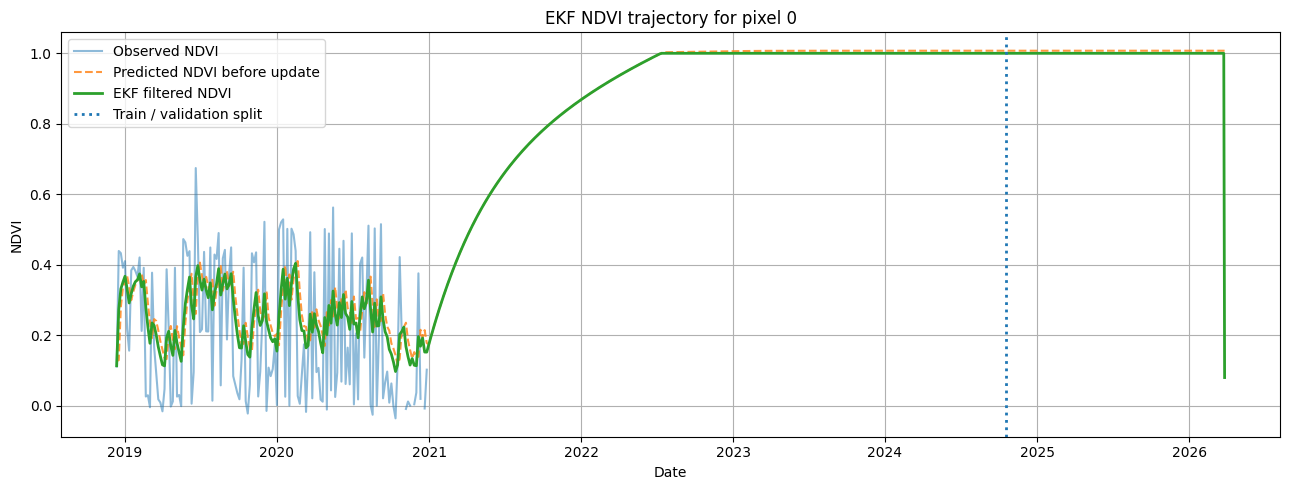

Saved: /content/drive/MyDrive/Archivos_Jammes/Proyecto/BiomasAndinos/Results/pixel_0_ndvi_ekf_trajectory.png


In [ ]:
# ==========================================
# F. PLOT ONE PIXEL
# ==========================================

selected_pixel = ekf_by_pixel["pixel_id"].unique()[0]

df_plot = ekf_by_pixel[ekf_by_pixel["pixel_id"] == selected_pixel].copy()

plt.figure(figsize=(13, 5))

plt.plot(
    df_plot["date"],
    df_plot["NDVI_observed"],
    label="Observed NDVI",
    alpha=0.5
)

plt.plot(
    df_plot["date"],
    df_plot["NDVI_predicted"],
    label="Predicted NDVI before update",
    linestyle="--",
    alpha=0.8
)

plt.plot(
    df_plot["date"],
    df_plot["NDVI_filtered"],
    label="EKF filtered NDVI",
    linewidth=2
)

plt.axvline(
    TRAIN_END_DATE,
    linestyle=":",
    linewidth=2,
    label="Train / validation split"
)

plt.xlabel("Date")
plt.ylabel("NDVI")
plt.title(f"EKF NDVI trajectory for pixel {selected_pixel}")
plt.legend()
plt.grid(True)
plt.tight_layout()

fig_path = PROJECT_DIR / f"pixel_{selected_pixel}_ndvi_ekf_trajectory.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)

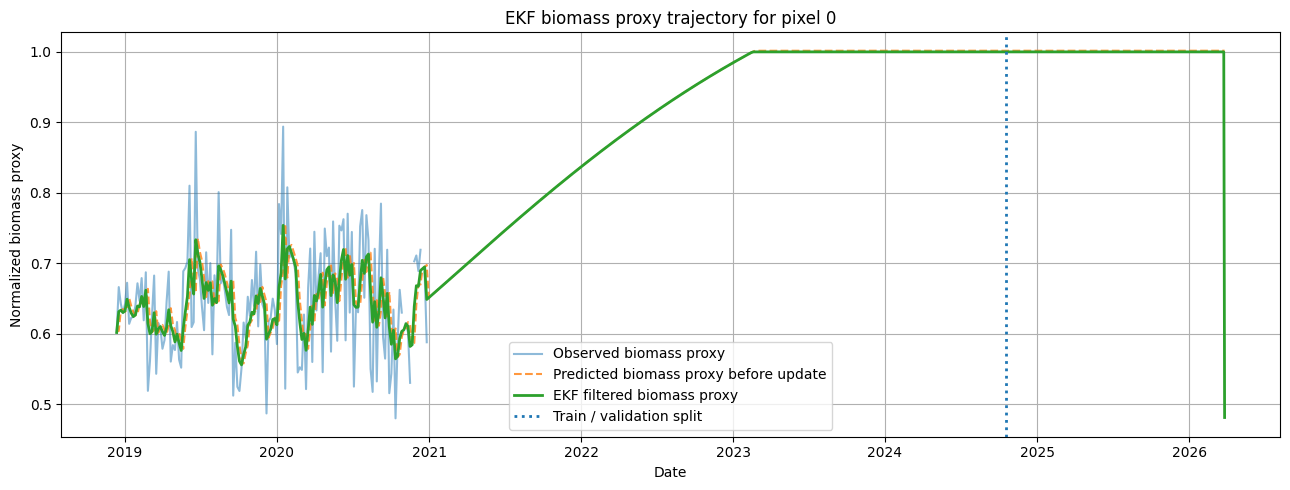

Saved: /content/drive/MyDrive/Archivos_Jammes/Proyecto/BiomasAndinos/Results/pixel_0_biomass_proxy_ekf_trajectory.png


In [ ]:
plt.figure(figsize=(13, 5))

plt.plot(
    df_plot["date"],
    df_plot["AGB_proxy_observed"],
    label="Observed biomass proxy",
    alpha=0.5
)

plt.plot(
    df_plot["date"],
    df_plot["AGB_proxy_predicted"],
    label="Predicted biomass proxy before update",
    linestyle="--",
    alpha=0.8
)

plt.plot(
    df_plot["date"],
    df_plot["AGB_proxy_filtered"],
    label="EKF filtered biomass proxy",
    linewidth=2
)

plt.axvline(
    TRAIN_END_DATE,
    linestyle=":",
    linewidth=2,
    label="Train / validation split"
)

plt.xlabel("Date")
plt.ylabel("Normalized biomass proxy")
plt.title(f"EKF biomass proxy trajectory for pixel {selected_pixel}")
plt.legend()
plt.grid(True)
plt.tight_layout()

fig_path = PROJECT_DIR / f"pixel_{selected_pixel}_biomass_proxy_ekf_trajectory.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)

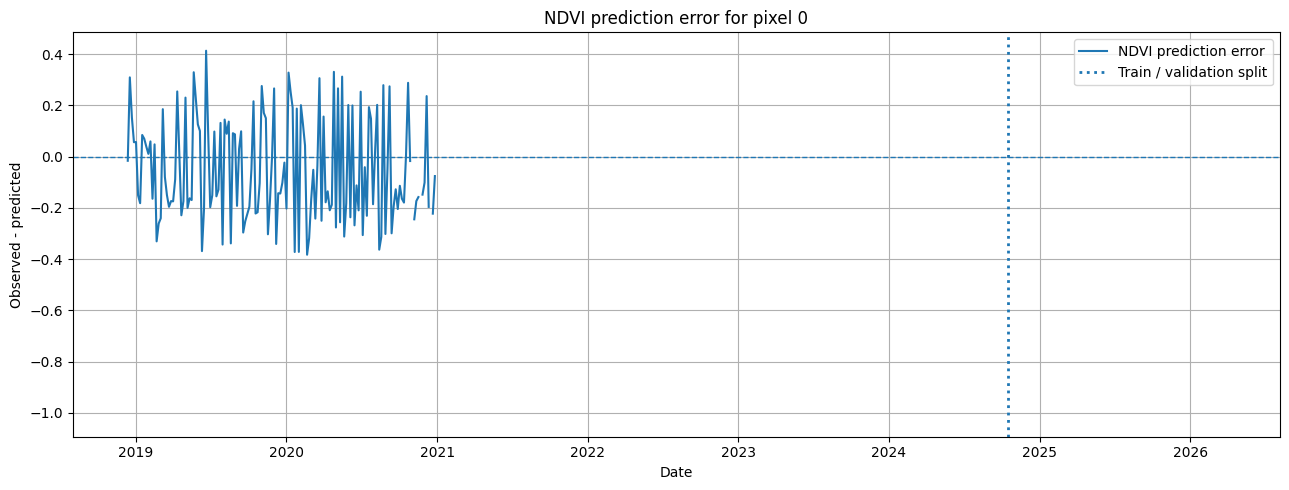

Saved: /content/drive/MyDrive/Archivos_Jammes/Proyecto/BiomasAndinos/Results/pixel_0_ndvi_prediction_error.png


In [ ]:
plt.figure(figsize=(13, 5))

plt.plot(
    df_plot["date"],
    df_plot["error_pred_NDVI"],
    label="NDVI prediction error"
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.axvline(
    TRAIN_END_DATE,
    linestyle=":",
    linewidth=2,
    label="Train / validation split"
)

plt.xlabel("Date")
plt.ylabel("Observed - predicted")
plt.title(f"NDVI prediction error for pixel {selected_pixel}")
plt.legend()
plt.grid(True)
plt.tight_layout()

fig_path = PROJECT_DIR / f"pixel_{selected_pixel}_ndvi_prediction_error.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)

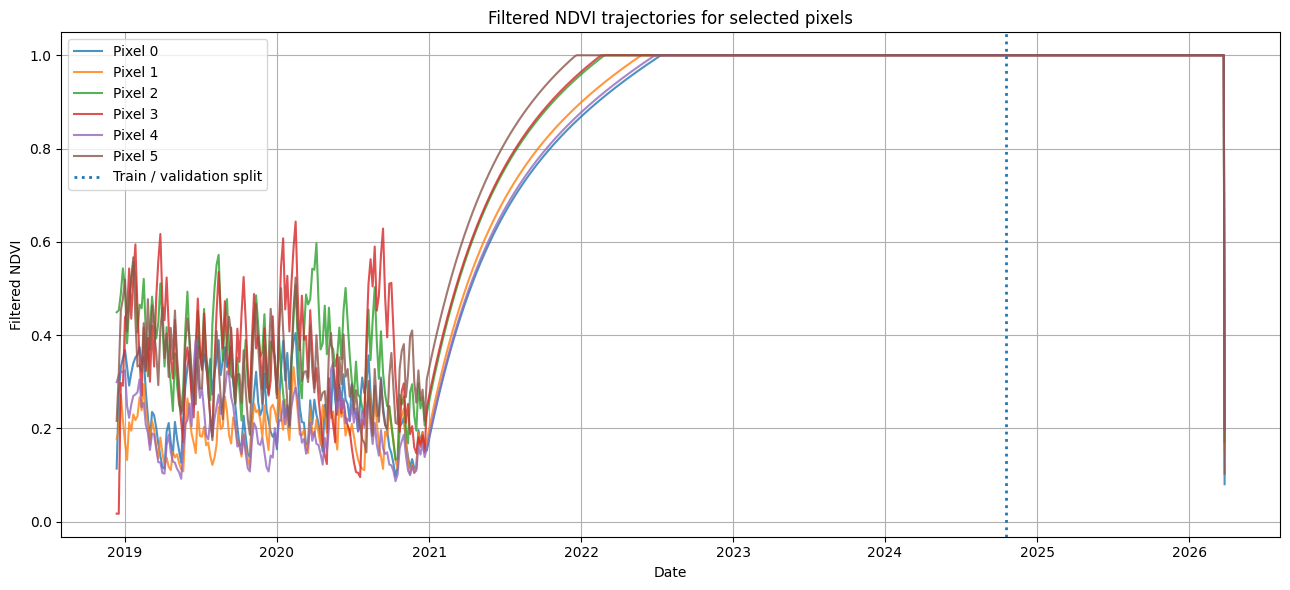

Saved: /content/drive/MyDrive/Archivos_Jammes/Proyecto/BiomasAndinos/Results/selected_pixels_filtered_ndvi.png


In [ ]:
# ==========================================
# I. PLOT MULTIPLE PIXELS
# ==========================================

selected_pixels = ekf_by_pixel["pixel_id"].unique()[:6]

plt.figure(figsize=(13, 6))

for pix in selected_pixels:
    temp = ekf_by_pixel[ekf_by_pixel["pixel_id"] == pix]

    plt.plot(
        temp["date"],
        temp["NDVI_filtered"],
        label=f"Pixel {pix}",
        alpha=0.8
    )

plt.axvline(
    TRAIN_END_DATE,
    linestyle=":",
    linewidth=2,
    label="Train / validation split"
)

plt.xlabel("Date")
plt.ylabel("Filtered NDVI")
plt.title("Filtered NDVI trajectories for selected pixels")
plt.legend()
plt.grid(True)
plt.tight_layout()

fig_path = PROJECT_DIR / "selected_pixels_filtered_ndvi.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)

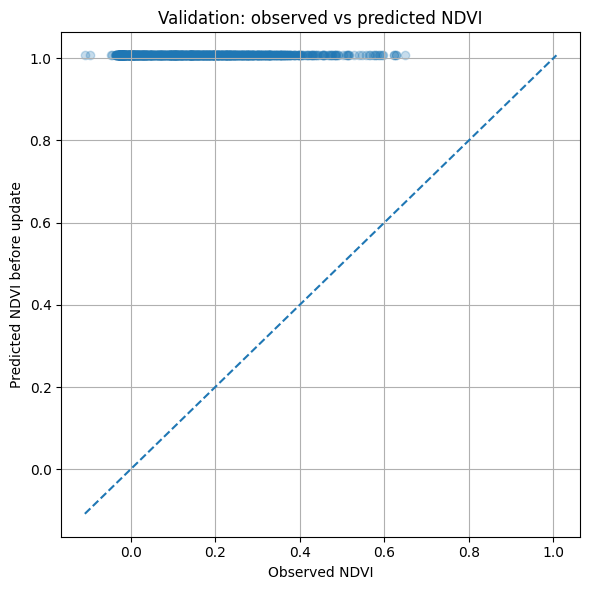

Saved: /content/drive/MyDrive/Archivos_Jammes/Proyecto/BiomasAndinos/Results/validation_observed_vs_predicted_ndvi.png


In [ ]:
# ==========================================
# J. OBSERVED VS PREDICTED VALIDATION PLOT
# ==========================================

plt.figure(figsize=(6, 6))

x = validation_df["NDVI_observed"]
y = validation_df["NDVI_predicted"]

plt.scatter(x, y, alpha=0.25)

min_val = np.nanmin([x.min(), y.min()])
max_val = np.nanmax([x.max(), y.max()])

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Observed NDVI")
plt.ylabel("Predicted NDVI before update")
plt.title("Validation: observed vs predicted NDVI")
plt.grid(True)
plt.tight_layout()

fig_path = PROJECT_DIR / "validation_observed_vs_predicted_ndvi.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)

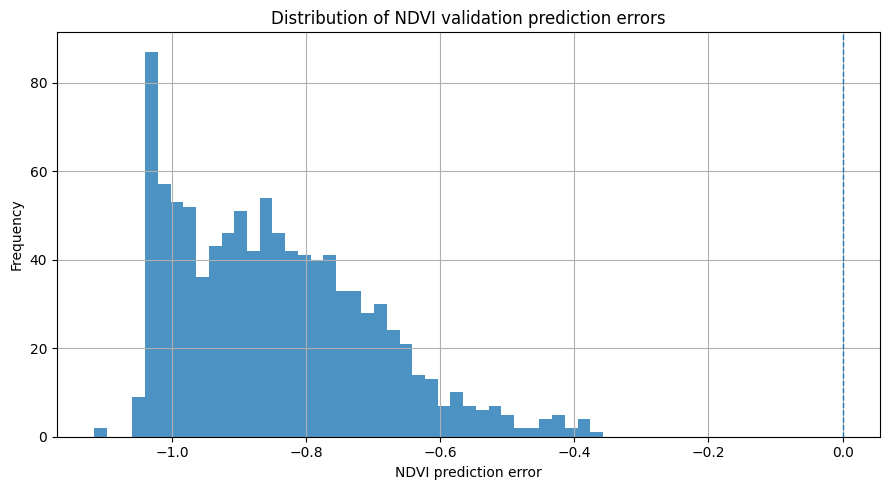

Saved: /content/drive/MyDrive/Archivos_Jammes/Proyecto/BiomasAndinos/Results/validation_ndvi_prediction_error_histogram.png


In [ ]:
# ==========================================
# K. HISTOGRAM OF VALIDATION ERRORS
# ==========================================

plt.figure(figsize=(9, 5))

plt.hist(
    validation_df["error_pred_NDVI"].dropna(),
    bins=40,
    alpha=0.8
)

plt.axvline(0, linestyle="--", linewidth=1)

plt.xlabel("NDVI prediction error")
plt.ylabel("Frequency")
plt.title("Distribution of NDVI validation prediction errors")
plt.grid(True)
plt.tight_layout()

fig_path = PROJECT_DIR / "validation_ndvi_prediction_error_histogram.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)

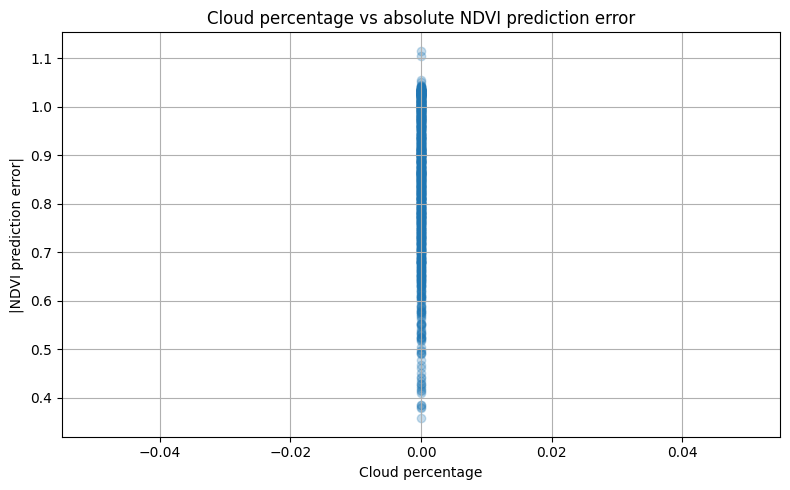

Saved: /content/drive/MyDrive/Archivos_Jammes/Proyecto/BiomasAndinos/Results/cloud_percentage_vs_ndvi_error.png


In [ ]:
# ==========================================
# L. CLOUD PERCENTAGE VS ERROR
# ==========================================

plt.figure(figsize=(8, 5))

plt.scatter(
    validation_df["CLOUD_PERCENTAGE"],
    np.abs(validation_df["error_pred_NDVI"]),
    alpha=0.25
)

plt.xlabel("Cloud percentage")
plt.ylabel("|NDVI prediction error|")
plt.title("Cloud percentage vs absolute NDVI prediction error")
plt.grid(True)
plt.tight_layout()

fig_path = PROJECT_DIR / "cloud_percentage_vs_ndvi_error.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)

In [ ]:
# ==========================================
# M. FINAL SUMMARY
# ==========================================

summary = {
    "train_end_date": str(TRAIN_END_DATE),
    "validation_start_date": str(VAL_START_DATE),
    "number_pixels": int(ekf_by_pixel["pixel_id"].nunique()),
    "number_total_rows": int(len(ekf_by_pixel)),
    "number_validation_rows": int(len(validation_df)),
    "mean_validation_NDVI_RMSE": float(metrics_df.loc[metrics_df["variable"] == "NDVI", "RMSE"].iloc[0]),
    "mean_validation_AGB_proxy_RMSE": float(metrics_df.loc[metrics_df["variable"] == "AGB_proxy", "RMSE"].iloc[0]),
}

summary_path = PROJECT_DIR / "ekf_validation_summary.json"

import json

with open(summary_path, "w") as f:
    json.dump(summary, f, indent=4)

print("Saved:", summary_path)
summary

Saved: /content/drive/MyDrive/Archivos_Jammes/Proyecto/BiomasAndinos/Results/ekf_validation_summary.json


{'train_end_date': '2024-10-17 00:00:00',
 'validation_start_date': '2024-10-22 00:00:00',
 'number_pixels': 1000,
 'number_total_rows': 534000,
 'number_validation_rows': 106000,
 'mean_validation_NDVI_RMSE': 0.8566008781994326,
 'mean_validation_AGB_proxy_RMSE': 0.3378386626951767}